# Validation of the DOS-convergence workflow

## Objective

Develop and validate a reusable workflow for producing DOS-similarity heatmaps from the FHI-aims numerical-quality dataset stored in NOMAD.

This notebook validates the workflow progressively:

1. Query NOMAD to discover the materials currently associated with the dataset DOI.
2. Process one material end-to-end.
3. Record its execution time and number of successfully retrieved calculations.
4. Run a five-material smoke test.
5. Confirm that the workflow saves the expected heatmaps and timing results.

After these tests succeed, the validated workflow will be applied to the complete material list in a separate notebook: `03_all_materials.ipynb`.

**In short:** this notebook tests the workflow on a small scale before the full dataset is processed.

## 1. Discover the materials in FHI-aims dataset.

Query NOMAD for the unique chemical formulas contained in the 'Numerical_Errors_FHI-aims' dataset. This step retrieves only summary metadata; it does not download the DOS data.

In [3]:
import requests

nomad_url = "https://nomad-lab.eu/prod/v1/api/v1/entries/query"

### Define the NOMAD material-discovery request

NOMAD contains many datasets and individual calculation entries. We therefore need to describe precisely which entries we want to examine and how NOMAD should summarize them.

The variable 'request_body' stores these instructions as a Python dictionary. It contains three main sections:

1. **'query'**
   This filters NOMAD's entries to those belonging to the dataset named 'Numerical_Errors_FHI-aims'. This prevents calculations from unrelated datasets or simulation programs from being included.

2. **'pagination'**
    NOMAD normally returns individual calculation entries in pages. Setting the outer 'page_size' to 0 tells NOMAD not to return these individiual entries at this stage. We currently only need a sumarry of the materials, not their complete calculation data.

3. **'aggregations'**
    An aggregation group matching entries according to a selected property. Here, NOMAD groups the calculations using 'results.material.chemical_formula_reduced'.
    A reduced chemical formula expresses a material's composition using the smallest whole-number ratio of its elements. Therefore, calculations with the same reduced formula are placed into the same material group.
    The inner 'page_size' is set to 1000, allowing the aggregations to return up to 1K distinct material formulas. This is safely above the number of materials in this dataset.

Request is only being defined, so no data gets downloaded.

**In short:** filter the FHI-aims dataset, avoiding individual calculations, and ask NOMAD for a grouped list of its unique material formulas.

In [12]:
# Store the set of instructions that will later be sent to NOMAD
request_body = {

    # Restrict the search to entries from the FHI-aims numerical-quality dataset.
    "query": {
        "datasets.doi": "10.17172/NOMAD/2020.07.27-1"    # Restricts the search using the dataset's unique DOI.
    },

    # Return 0 individual calculation entries because we currently only want a summary
    "pagination": {
        "page_size": 0
        },
    # Group the matching calculations according to their material formula
    "aggregations": {

        # 'materials' is our chosen name for this grouped result.
        "materials": {
            "terms": {

                # Use each material's reduced chemical formula as the grouping property.
                "quantity": "results.material.chemical_formula_reduced",

                # Permit up to 1000 distinct formulas in the returned summary.
                "pagination": {"page_size": 1000}
            }
        }
    }
}

### Send the request to NOMAD

The previous cell constructed the instructions but did not communicate with NOMAD. The next cell will send those instructions to the NOMAD API.

NOMAD will process the request and return an HTTP response. We will then check whether the request succeeded before attempting to extract any material formulas.

**In short:** send the prepared material-discovery request and verify that NOMAD accepted it.

In [16]:
# Send the prepared dictionary to NOMAD using an HTTP POST request.
response = requests.post(
    nomad_url,            # Address of the NOMAD query endpoint,
    json = request_body,  # Convert and send our Python dict as JSON.
    timeout = 120         # Stop waiting if NOMAD takes longer than 120 seconds.
)

# Raise an exception if NOMAD returned an HTTP error.
response.raise_for_status()

# Display NOMAD's HTTP status code. A result of 200 means the request succeeded.
print("HTTP status:", response.status_code)

HTTP status: 200


### Extract the material formulas

NOMAD returned its response as JSON. The response contains several sections, but the required information is inside the material aggregation.

Each aggregation group contains:

- `value`: the reduced chemical formula.
- `count`: the number of calculation entries assigned to that formula.

The following code extracts these groups, stores each formula together with its calculation count, and sorts the formulas alphabetically.

**In short:** transform NOMAD's response into a usable list of materials and their corresponding calculation counts.

In [17]:
# Convert NOMAD's JSON response into Python dicts and lists.
response_data = response.json()

# Extract the groups created by the material-formula aggregation.
material_group = response_data["aggregations"]["materials"]["terms"]["data"]

# Create an empty dict for storing each formula and its calculation count.
material_counts = {}

# Examine every material group returned by NOMAD.
for group in material_group:
    formula = group["value"]                 # The material's reduced chemical formula.
    calculation_count = group["count"]       # No. of calculation entries in the group.
    material_counts[formula] = calculation_count

# Display the total number of unique formulas
materials = sorted(material_counts)

# Display the total number of unique formulas
print("Number of materials:", len(materials))

# Display the first ten formulas and their calculation counts.
for formula in materials[:10]:
    print(formula, material_counts[formula])


Number of materials: 161
Ac2Cl6 288
Ag4 321
Ag4Cl4 288
AgKO3 144
Al4 327
Al4P4 288
AlGaO3 144
Ar4 321
As4Ga4 288
As6 323


### Dataset-size observation

The associated paper reports **144 materials**: 71 elemental, 63 binary, and 10 ternary systems. However, the current DOI-specific NOMAD query returns **161 distinct reduced chemical formulas**.

The reason for this difference has not been established here. 

The workflow developed here will use the 161-material list returned by NOMAD. After validation, a separate notebook will apply the workflow to all 161 materials.

## 2. Validate one material end-to-end


Before testing repeated execution, process one material through the complete workflow. This checks data retrieval, DOS-fingerprint generation, similarity-matrix calculation, heatmap creation, file saving, and runtime measurement.

AlGaO₃ is used because it is the example previously reproduced from the MADAS notebook.

**In short:** confirm that every stage works correctly for one material.

### Import the required tools

The following cell loads tools for:

- measuring execution time;
- creating output folders and file paths;
- processing numerical arrays;
- retrieving and storing NOMAD calculations;
- generating DOS fingerprints;
- extracting FHI-aims calculation settings;
- creating the similarity heatmap.

Importing these tools does not retrieve or process any material data.

**In short:** prepare the Python tools required by the workflow.

In [25]:
# Path helps create platform-independent folders and filenames.
from pathlib import Path

# perf_counter measures elapsed execution time accurately.
from time import perf_counter

# NumPy provides numerical-array operations.
import numpy as np

# Import MADAS's local database manager.
from madas import MaterialsDatabase

# Import MADAS's interface for retrieving calculations from NOMAD.
from madas.apis.NOMAD_web_API import API

# Import the MADAS fingerprint used to represent and compare DOS curves.
from madas.fingerprints import DOSFingerprint

# Import functions that extract the required values from NOMAD archives.
from processing_functions import (
    get_dos_values,
    get_dos_energies_vbm,
    get_FHIaims_kpoints,
    get_FHIaims_n_basis_functions,
)

# Import the plotting function used by the original example.
from plotting_functions import similarity_kpoint_nfunc_plot

### Configure the AlGaO₃ test

MADAS must know which information to extract from each NOMAD calculation. The processing configuration below tells it to extract:

- the DOS values;
- the DOS energy grid relative to the valence-band maximum;
- the FHI-aims k-point grid;
- the number of FHI-aims basis functions.

The query then selects only AlGaO₃ calculations belonging to the chosen DOI dataset and containing electronic DOS data.

This cell only defines the configuration and query; it does not download anything.

**In short:** specify which material to retrieve and which information to extract.

In [26]:
# Select the material used for the one-material validation.
test_formula = "AlGaO3"

# Copy MADAS's default NOMAD processing configuration.
processing = API().processing.copy()

# Remove the complete archive because only selected quantities are needed.
processing.pop("archive", None)

# Define how MADAS should extract the required DOS and numerical-setting data.
processing["electronic_dos_values"] = get_dos_values
processing["electronic_dos_energies"] = get_dos_energies_vbm
processing["kpoints"] = get_FHIaims_kpoints
processing["n_basis_functions"] = get_FHIaims_n_basis_functions

# Create a NOMAD query restricted to AlGaO3 entries in the selected DOI dataset.
test_query = {
    "datasets.doi": "10.17172/NOMAD/2020.07.27-1",
    "results.material.chemical_formula_reduced": test_formula,
    "results.properties.available_properties:all": ["dos_electronic"],
}

In [27]:
# Import Python's inspection tool for examining functions and classes.
import inspect

# Display the arguments accepted when creating a NOMAD API object.
print("API constructor:", inspect.signature(API))

# Display the arguments accepted by MADAS's database-download method.
print("fill_database method:", inspect.signature(MaterialsDatabase.fill_database))

API constructor: (processing={'atoms': <function get_atoms at 0x7587960f3060>, 'archive': <function get_archive at 0x758796123c40>}, logger=None)
fill_database method: (self, *args, repeat_query: bool = False, **kwargs)


In [28]:
# Display the arguments accepted by MADAS's NOMAD calculation-retrieval method.
print(
    "NOMAD retrieval method:",
    inspect.signature(API.get_calculations_by_search)
)

NOMAD retrieval method: (self, query: dict, required: dict = {'required': '*'}, n_threads: int = 5, max_entries: int | None = None, ignore_entries: list | None = None) -> List[madas.material.Material]


### Create a fresh validation database

MADAS stores retrieved calculations in a local SQLite database. A new database is used here so that the measured retrieval time represents an actual NOMAD query rather than reading previously cached data.

No material calculations are downloaded in this cell.

**In short:** prepare an empty local database for the timed AlGaO₃ test.

In [30]:
# Choose a descriptive filename for the local validation database.
database_filename = "validation_AlGaO3.db"

# Construct the path where MADAS normally stores notebook databases.
database_path = Path("data") / database_filename

# Refuse to reuse an existing database because that would invalidate the timing test.
if database_path.exists():
    raise FileExistsError(
        f"{database_path} already exists; choose a new filename for a fresh timing run."
    )

# Create the empty database and connect it to the configured NOMAD API.
db = MaterialsDatabase(
    filename=database_filename,
    api=API(processing=processing),
)

# Confirm that the new database contains no calculations.
print("Initial database entries:", len(db))

Initial database entries: 0


### Retrieve the AlGaO₃ calculations

This step sends the AlGaO₃ query to NOMAD, retrieves the matching calculation archives, extracts the required quantities, and stores the successfully processed calculations in the local database.

The retrieval explicitly uses one thread. The elapsed wall-clock time is recorded separately because NOMAD communication is expected to be the slowest and most variable stage.

**In short:** download and time the AlGaO₃ data using one retrieval thread.

In [31]:
# Record the precise time immediately before starting the NOMAD retrieval.
retrieval_start = perf_counter()

# Retrieve matching calculations sequentially and store successful results locally.
db.fill_database(
    test_query,
    n_threads=1,
)

# Calculate the elapsed wall-clock time for the complete retrieval stage.
retrieval_seconds = perf_counter() - retrieval_start

# Report the number of calculations that were successfully stored.
print("Successful calculations:", len(db))

# Report the retrieval duration in seconds and minutes.
print(f"Retrieval time: {retrieval_seconds:.2f} seconds")
print(f"Retrieval time: {retrieval_seconds / 60:.2f} minutes")

2026-08-03 10:12:33,498 - validation_AlGaO3_log - INFO - Retrieving data...
2026-08-03 10:12:42,297 - validation_AlGaO3_api - INFO - Found 144 entries
2026-08-03 10:13:50,131 - validation_AlGaO3_api - INFO - Finished download.
2026-08-03 10:13:50,133 - validation_AlGaO3_api - ERROR - Could not get calculation _JNthhZHIKa8Irdut6UIIwA5ZSd4, because of error 'data' with traceback Traceback (most recent call last):
  File "/home/ahmed/SOL_Research/.venv/lib/python3.12/site-packages/madas/apis/NOMAD_web_API.py", line 158, in get_calculation
    resp = resp["data"]
           ~~~~^^^^^^^^
KeyError: 'data'
.
2026-08-03 10:13:50,135 - validation_AlGaO3_api - ERROR - Could not get calculation knI8BK9-rtGWJE0rFQ5sdblyv0kZ, because of error 'data' with traceback Traceback (most recent call last):
  File "/home/ahmed/SOL_Research/.venv/lib/python3.12/site-packages/madas/apis/NOMAD_web_API.py", line 158, in get_calculation
    resp = resp["data"]
           ~~~~^^^^^^^^
KeyError: 'data'
.
2026-08-0

Successful calculations: 78
Retrieval time: 77.24 seconds
Retrieval time: 1.29 minutes


In [32]:
# Display the arguments accepted by Martin's retry method.
print("Retry method:", inspect.signature(API.retry))

Retry method: (self, required: dict = {'required': '*'}, use_progress_bar: bool = False) -> List[madas.material.Material]


### Retry failed AlGaO₃ entries once

Some NOMAD archives may fail during the initial retrieval. Following the original notebook, retry these entries once and add any successfully recovered calculations to the local database.

Remaining failures are recorded implicitly through the final calculation count but are not investigated in this validation.

**In short:** make one recovery attempt, then continue with the available calculations.

In [33]:
# Start measuring the retry stage.
retry_start = perf_counter()

# Retry the calculations that failed during the initial NOMAD retrieval.
retried_materials = db.api.retry(use_progress_bar=True)

# Add successfully recovered calculations to the local database.
if len(retried_materials) > 0:
    db.backend.add_many(retried_materials)

# Calculate the duration of the retry stage.
retry_seconds = perf_counter() - retry_start

# Combine the initial retrieval and retry durations.
total_retrieval_seconds = retrieval_seconds + retry_seconds

# Report how many calculations are now available and how long retrieval took overall.
print("Recovered calculations:", len(retried_materials))
print("Final successful calculations:", len(db))
print(f"Retry time: {retry_seconds:.2f} seconds")
print(f"Total retrieval time: {total_retrieval_seconds:.2f} seconds")
print(f"Total retrieval time: {total_retrieval_seconds / 60:.2f} minutes")

2026-08-03 10:18:28,188 - validation_AlGaO3_api - INFO - Retrying 66 entries.


  0%|          | 0/66 [00:00<?, ?it/s]

2026-08-03 10:18:43,385 - validation_AlGaO3_api - ERROR - Retry failed for material with entry_id cppz0RPbeRC1oAkwQg22IxLkyO4E. Error message: 'data'
2026-08-03 10:18:44,149 - validation_AlGaO3_api - ERROR - Retry failed for material with entry_id rQiR-uD2Q8Oew95dbpoPvPRE0B2E. Error message: 'data'
2026-08-03 10:18:44,310 - validation_AlGaO3_api - ERROR - Retry failed for material with entry_id jovrIbBF7Th21yWZD-fbuiabGrpd. Error message: 'data'
2026-08-03 10:18:45,154 - validation_AlGaO3_api - ERROR - Retry failed for material with entry_id Hyp24qZitUNfcK6dxsB1RS2mb81y. Error message: 'data'
2026-08-03 10:18:45,313 - validation_AlGaO3_api - ERROR - Retry failed for material with entry_id t9r6EdVxb5aH5_rR5sj2pyAiMVqt. Error message: 'data'
2026-08-03 10:18:46,170 - validation_AlGaO3_api - ERROR - Retry failed for material with entry_id DQ0NvQXNliRoMXXb1sBtDApE0XGc. Error message: 'data'
2026-08-03 10:18:46,311 - validation_AlGaO3_api - ERROR - Retry failed for material with entry_id Fs

Recovered calculations: 40
Final successful calculations: 118
Retry time: 30.17 seconds
Total retrieval time: 107.40 seconds
Total retrieval time: 1.79 minutes


### Generate DOS fingerprints

Each successfully retrieved DOS curve is converted into a standardized DOS fingerprint. This makes DOS curves produced with different numerical settings directly comparable.

Following the original notebook, the fingerprint grid uses 2048 pixels across an energy range from −8 eV to +12 eV relative to the valence-band maximum.

**In short:** convert every available DOS curve into the same numerical representation.

In [34]:
# Create the same high-resolution DOS grid used in Martin's notebook.
grid = DOSFingerprint.get_default_grid().create(
    n_pix=2048,
    cutoff=[-8, 12],
)

# Start measuring fingerprint generation.
fingerprint_start = perf_counter()

# Generate and store one DOS fingerprint for every calculation in the database.
db.add_fingerprint(
    "DOS",
    fingerprint_kwargs={"grid_id": grid.get_grid_id()},
)

# Calculate the elapsed fingerprint-generation time.
fingerprint_seconds = perf_counter() - fingerprint_start

# Report the completed stage and its runtime.
print("Fingerprints generated:", len(db))
print(f"Fingerprint time: {fingerprint_seconds:.2f} seconds")

2026-08-03 10:20:08,629 - validation_AlGaO3_log - INFO - Generating DOS fingerprints...
2026-08-03 10:20:08,634 - validation_AlGaO3_log - INFO - Generating "DOS" fingerprints.


  0%|          | 0/118 [00:00<?, ?it/s]

2026-08-03 10:21:24,393 - validation_AlGaO3_log - INFO - Writing DOS fingerprints to database...
2026-08-03 10:21:24,924 - validation_AlGaO3_log - INFO - Finished generation of DOS fingerprints.


Fingerprints generated: 118
Fingerprint time: 76.30 seconds


### Calculate the DOS-similarity matrix

The similarity matrix compares every available AlGaO₃ DOS fingerprint with every other fingerprint. Each matrix cell contains a similarity coefficient between two calculations.

A value closer to 1 indicates more similar DOS shapes, while lower values indicate greater disagreement between calculations.

**In short:** compare every available AlGaO₃ calculation with every other calculation.

In [35]:
# Start measuring the similarity-matrix calculation.
similarity_start = perf_counter()

# Calculate the same DOS similarity matrix used in Martin's notebook.
simat = db.get_similarity_matrix(
    "DOS",
    name="DOS",
)

# Calculate the elapsed similarity-matrix time.
similarity_seconds = perf_counter() - similarity_start

# Report the number of calculations represented by the square matrix.
print("Similarity-matrix size:", len(simat.mids), "x", len(simat.mids))

# Report the runtime of this stage.
print(f"Similarity-matrix time: {similarity_seconds:.2f} seconds")

2026-08-03 10:22:42,968 - validation_AlGaO3_log - INFO - Fingerprints with name "DOS" exist. Reading from database.


  0%|          | 0/118 [00:00<?, ?it/s]

Similarity-matrix size: 118 x 118
Similarity-matrix time: 12.84 seconds


### Sort the calculations and collect their numerical settings

The calculations are ordered by their average DOS similarity to the rest of the dataset. This ordering makes groups of poorly converged and highly similar calculations easier to recognize in the heatmap.

For each ordered calculation, retrieve:

- the total number of k-points;
- the number of basis functions.

The similarity matrix is then rearranged to follow the same order.

**In short:** arrange the matrix meaningfully and prepare the settings shown beneath the heatmap.

In [36]:
# Import MADAS's progress-bar utility used in Martin's notebook.
from madas.utils import tqdm

# Start measuring preparation of the ordered plotting data.
preparation_start = perf_counter()

# Sort calculation IDs by their mean similarity to all other calculations.
sorted_mids = sorted(
    simat.mids,
    key=lambda mid: np.mean(simat[mid]),
)

# Create empty lists for the numerical settings associated with each calculation.
nfunc = []
kpoints = []

# Read each calculation in the newly determined order.
for mid in tqdm(sorted_mids):
    entry = db[mid]

    # Store the calculation's number of basis functions.
    nfunc.append(entry.data["n_basis_functions"])

    # Multiply the three k-point-grid dimensions to obtain the total k-point count.
    kpoints.append(np.prod(entry.data["kpoints"]))

# Rearrange both axes of the similarity matrix into the same order.
simat.get_sub_matrix(sorted_mids, copy=False)

# Calculate the elapsed data-preparation time.
preparation_seconds = perf_counter() - preparation_start

# Confirm the number of prepared calculations and report the runtime.
print("Prepared calculations:", len(sorted_mids))
print(f"Preparation time: {preparation_seconds:.2f} seconds")

  0%|          | 0/118 [00:00<?, ?it/s]

Prepared calculations: 118
Preparation time: 0.48 seconds


### Generate and save the AlGaO₃ heatmap

Martin’s plotting function combines the ordered similarity matrix with the corresponding k-point counts and basis-function counts.

The heatmap is saved as a PNG file inside `results/validation`. The total workflow time is calculated by adding the measured durations of retrieval, retry, fingerprint generation, similarity calculation, data preparation, and plotting.

**In short:** produce the deliverable and record the complete processing time.

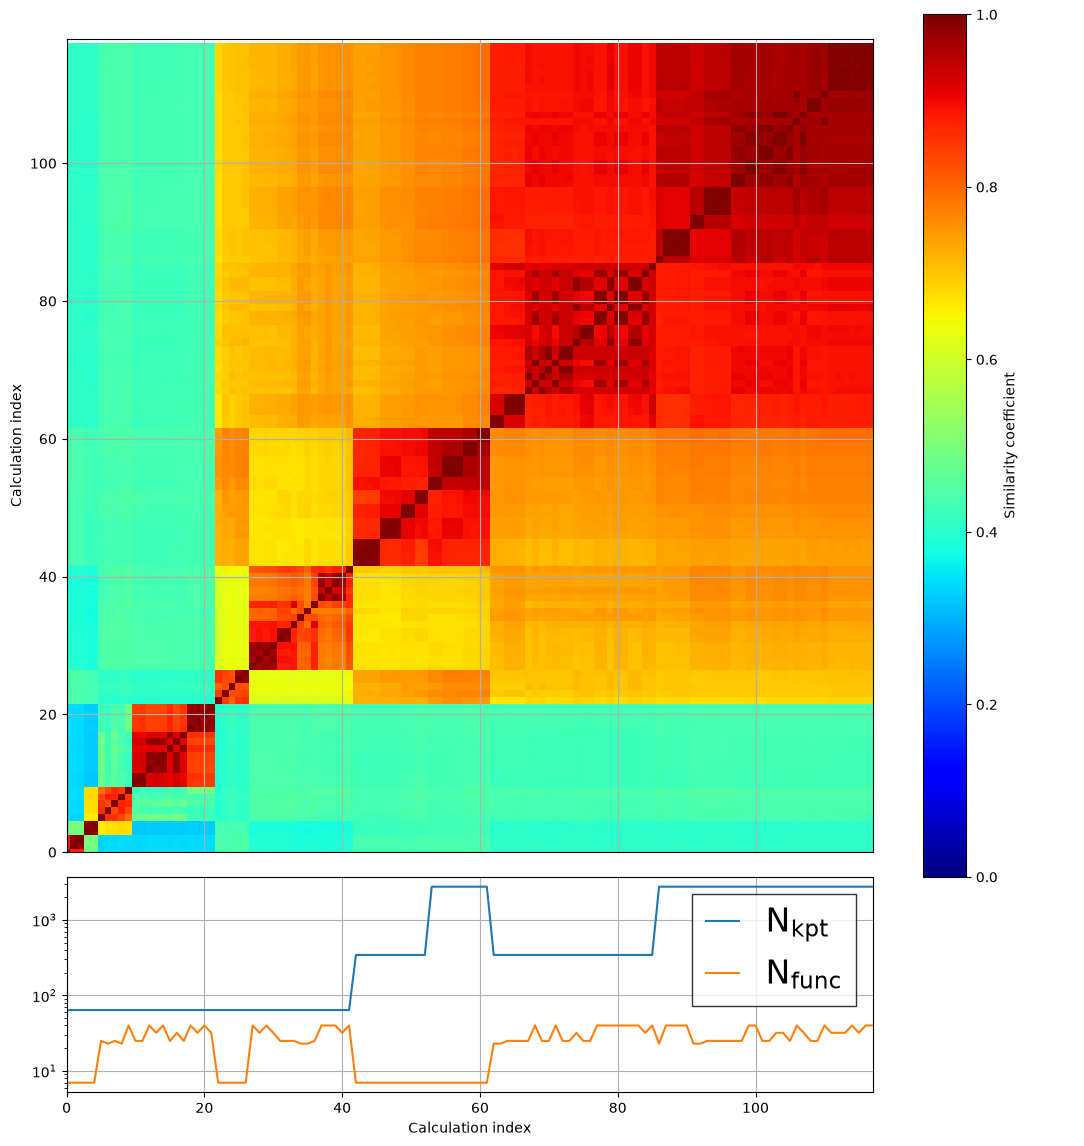

Saved heatmap: /home/ahmed/SOL_Research/dos-convergence-analysis/results/validation/AlGaO3_DOS_similarity_heatmap.png
Plotting time: 1.11 seconds
Total workflow time: 198.14 seconds
Total workflow time: 3.30 minutes


In [37]:
# Determine the repository root regardless of where Jupyter was launched.
project_root = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

# Define a dedicated folder for validation results.
output_directory = project_root / "results" / "validation"

# Create the output folder and any missing parent folders.
output_directory.mkdir(parents=True, exist_ok=True)

# Define the complete filename of the saved AlGaO3 heatmap.
heatmap_path = output_directory / "AlGaO3_DOS_similarity_heatmap.png"

# Start measuring heatmap generation.
plot_start = perf_counter()

# Generate and save the same combined heatmap used in Martin's example.
similarity_kpoint_nfunc_plot(
    simat,
    kpoints,
    nfunc,
    filename=str(heatmap_path),
    cmap="jet",
)

# Calculate the plotting duration.
plot_seconds = perf_counter() - plot_start

# Add all measured stages to obtain the complete workflow runtime.
total_workflow_seconds = (
    total_retrieval_seconds
    + fingerprint_seconds
    + similarity_seconds
    + preparation_seconds
    + plot_seconds
)

# Report the saved file and final timing results.
print("Saved heatmap:", heatmap_path)
print(f"Plotting time: {plot_seconds:.2f} seconds")
print(f"Total workflow time: {total_workflow_seconds:.2f} seconds")
print(f"Total workflow time: {total_workflow_seconds / 60:.2f} minutes")

### One-material validation result

The complete AlGaO₃ workflow executed successfully and produced a saved DOS-similarity heatmap.

- Calculations expected from the live query: **144**
- Calculations successfully processed after one retry: **118**
- Total retrieval time: **107.40 seconds**
- DOS-fingerprint generation time: **76.30 seconds**
- Similarity-matrix calculation time: **12.84 seconds**
- Plotting time: **1.11 seconds**
- Complete measured workflow time: **198.14 seconds (3.30 minutes)**

The missing calculations are not investigated in this validation. The workflow continues using the successfully processed calculations.

**Conclusion:** the complete workflow works for one material and is ready for a five-material smoke test.